In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df1 = pd.read_csv(r"C:\Users\dell\OneDrive\Documents\AAAU.csv")
df2 = pd.read_csv(r"C:\Users\dell\OneDrive\Documents\AADR.csv")

In [5]:
df1.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,15-08-2018,11.84,11.84,11.74,11.74,11.74,27300
1,16-08-2018,11.78,11.80,11.74,11.74,11.74,428400
2,17-08-2018,11.80,11.82,11.77,11.82,11.82,52400
3,20-08-2018,11.88,11.91,11.85,11.90,11.90,28700
4,21-08-2018,11.92,11.95,11.89,11.93,11.93,30600


In [6]:
df2.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,21-07-2010,25.100000,25.100000,24.700001,24.700001,23.343714,42000
1,22-07-2010,25.420000,25.420000,25.129999,25.260000,23.872967,17500
2,23-07-2010,25.540001,25.540001,25.080000,25.280001,23.891865,8600
3,26-07-2010,25.400000,25.400000,25.219999,25.370001,23.976921,18900
4,27-07-2010,25.250000,25.290001,25.200001,25.290001,23.901318,8200


In [9]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 410 entries, 0 to 409
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       410 non-null    str    
 1   Open       410 non-null    float64
 2   High       410 non-null    float64
 3   Low        410 non-null    float64
 4   Close      410 non-null    float64
 5   Adj Close  410 non-null    float64
 6   Volume     410 non-null    int64  
 7   Stock      410 non-null    str    
dtypes: float64(5), int64(1), str(2)
memory usage: 25.8 KB


In [10]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 2442 entries, 0 to 2441
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2442 non-null   str    
 1   Open       2442 non-null   float64
 2   High       2442 non-null   float64
 3   Low        2442 non-null   float64
 4   Close      2442 non-null   float64
 5   Adj Close  2442 non-null   float64
 6   Volume     2442 non-null   int64  
 7   Stock      2442 non-null   str    
dtypes: float64(5), int64(1), str(2)
memory usage: 152.8 KB


In [7]:
df1['Stock'] = 'AAAU'
df2['Stock'] = 'AADR'

In [8]:
df = pd.concat([df1, df2])

In [12]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df = df.sort_values(['Stock', 'Date'])
df = df.dropna()

In [13]:
df.head()
df.info()

<class 'pandas.DataFrame'>
Index: 2852 entries, 0 to 2441
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       2852 non-null   datetime64[us]
 1   Open       2852 non-null   float64       
 2   High       2852 non-null   float64       
 3   Low        2852 non-null   float64       
 4   Close      2852 non-null   float64       
 5   Adj Close  2852 non-null   float64       
 6   Volume     2852 non-null   int64         
 7   Stock      2852 non-null   str           
dtypes: datetime64[us](1), float64(5), int64(1), str(1)
memory usage: 200.5 KB


In [14]:
df['MA_10'] = df.groupby('Stock')['Close'].transform(lambda x: x.rolling(10).mean())
df['MA_50'] = df.groupby('Stock')['Close'].transform(lambda x: x.rolling(50).mean())

In [15]:
df['Price_Change'] = df.groupby('Stock')['Close'].pct_change()

In [16]:
df['Next_Close'] = df.groupby('Stock')['Close'].shift(-1)
df['Actual'] = (df['Next_Close'] > df['Close']).astype(int)

In [17]:
df['Prediction'] = np.where(df['MA_10'] > df['MA_50'], 1, 0)

In [18]:
df = df.dropna()

In [19]:
accuracy = (df['Prediction'] == df['Actual']).mean()
print("Overall Accuracy:", accuracy)

Overall Accuracy: 0.4941860465116279


In [20]:
accuracy_stock = df.groupby('Stock').apply(
    lambda x: (x['Prediction'] == x['Actual']).mean()
)

print("\nAccuracy by Stock:")
print(accuracy_stock)


Accuracy by Stock:
Stock
AAAU    0.505556
AADR    0.492475
dtype: float64


In [21]:
tp = len(df[(df['Prediction']==1) & (df['Actual']==1)])
tn = len(df[(df['Prediction']==0) & (df['Actual']==0)])
fp = len(df[(df['Prediction']==1) & (df['Actual']==0)])
fn = len(df[(df['Prediction']==0) & (df['Actual']==1)])

print("\nConfusion Matrix:")
print("TP:", tp, "TN:", tn, "FP:", fp, "FN:", fn)


Confusion Matrix:
TP: 811 TN: 549 FP: 907 FN: 485


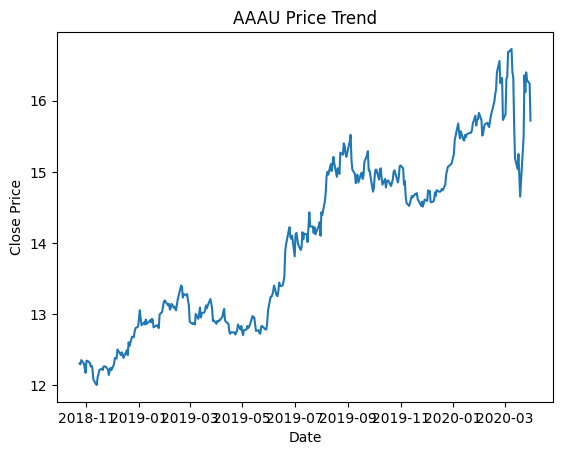

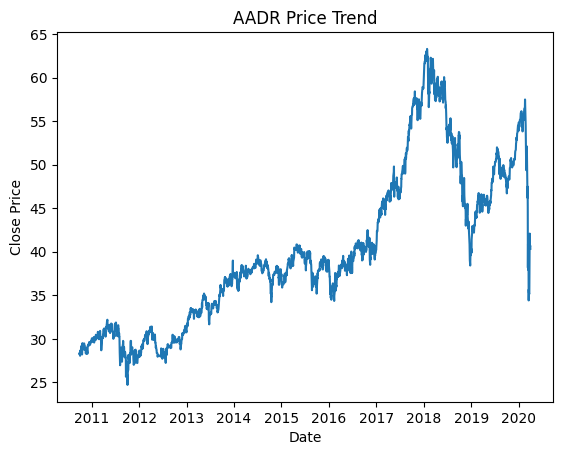

In [22]:
stocks = df['Stock'].unique()

for stock in stocks:
    temp = df[df['Stock'] == stock]

    plt.figure()
    plt.plot(temp['Date'], temp['Close'])
    plt.title(f"{stock} Price Trend")
    plt.xlabel("Date")
    plt.ylabel("Close Price")
    plt.show()

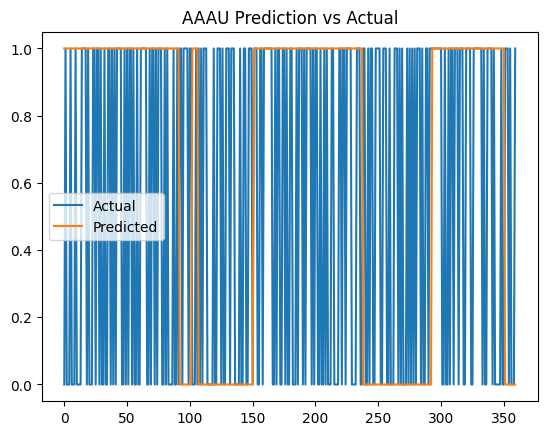

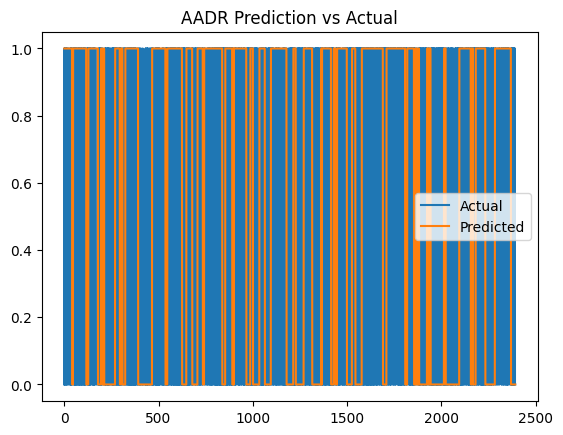

In [23]:
for stock in stocks:
    temp = df[df['Stock'] == stock]

    plt.figure()
    plt.plot(temp['Actual'].values, label='Actual')
    plt.plot(temp['Prediction'].values, label='Predicted')
    plt.legend()
    plt.title(f"{stock} Prediction vs Actual")
    plt.show()

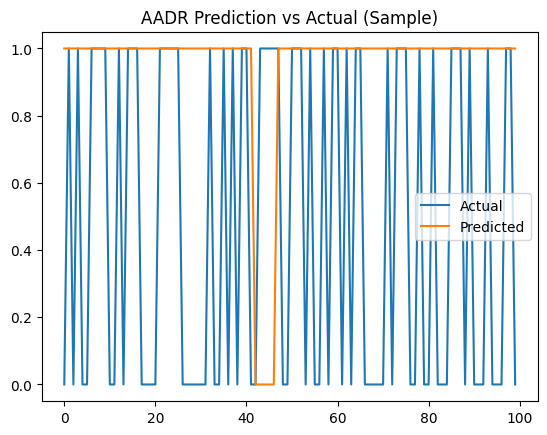

In [24]:
sample = temp.iloc[:100]

plt.figure()
plt.plot(sample['Actual'].values, label='Actual')
plt.plot(sample['Prediction'].values, label='Predicted')
plt.legend()
plt.title(f"{stock} Prediction vs Actual (Sample)")
plt.show()

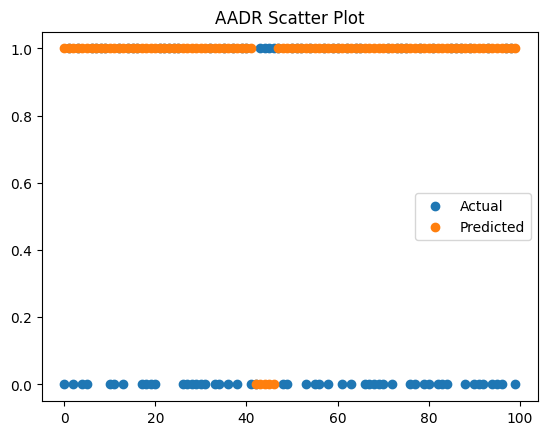

In [25]:
plt.figure()
plt.scatter(range(len(sample)), sample['Actual'], label='Actual')
plt.scatter(range(len(sample)), sample['Prediction'], label='Predicted')
plt.legend()
plt.title(f"{stock} Scatter Plot")
plt.show()

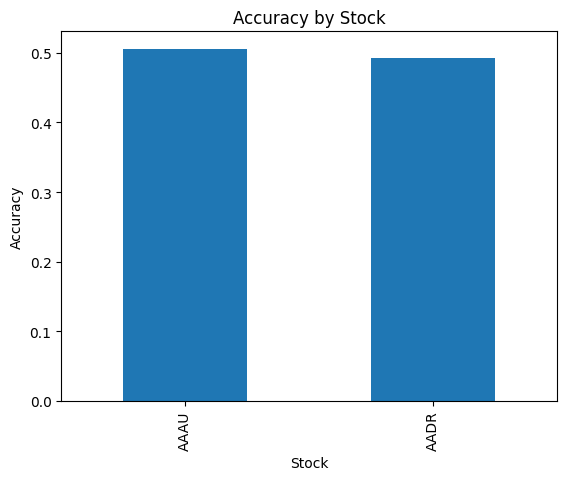

In [26]:
accuracy_stock.plot(kind='bar')
plt.title("Accuracy by Stock")
plt.ylabel("Accuracy")
plt.show()

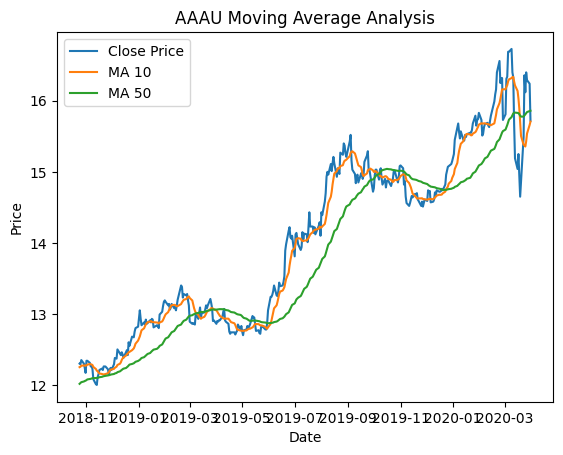

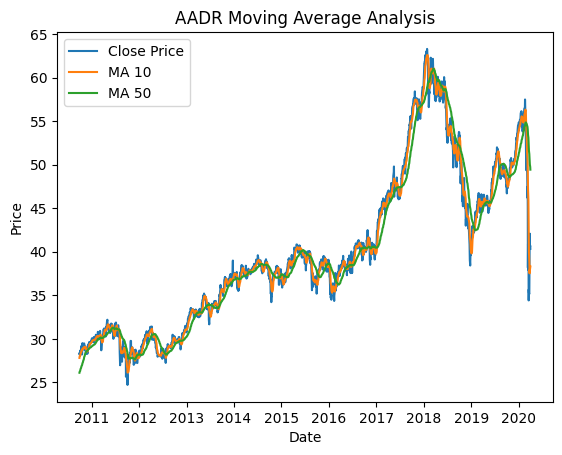

In [27]:
stocks = df['Stock'].unique()

for stock in stocks:
    temp = df[df['Stock'] == stock]

    plt.figure()
    plt.plot(temp['Date'], temp['Close'], label='Close Price')
    plt.plot(temp['Date'], temp['MA_10'], label='MA 10')
    plt.plot(temp['Date'], temp['MA_50'], label='MA 50')

    plt.title(f"{stock} Moving Average Analysis")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()
    plt.show()